# Repeat the simulation

In the last section, you simulated 10 coin tosses and counted how many times you got heads.
You might have obtained exactly 5 heads, or perhaps slightly more or fewer. This is normal as we were simulating a fair coin. 

So far, so good.

But what if we want to quantify how often each possible outcome occurs?
In other words, how often do we get $k = 0, 1, 2, \dots, 5, \dots, 9, 10$ heads out of 10 tosses?

To answer that, we need to run our *experiment* (tossing the coin 10 times and counting the number of heads) not just once, but lots of times.

Fortunately, the computer can easily do this thousands of times in a few milliseconds.

### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings 
warnings.simplefilter('ignore', category=FutureWarning)

## 10,000 times 10 coin tosses

We’re now going to simulate tossing the coin 10 times and counting how many heads we get, not just once, but 10,000 times in total. This will give us a clear picture of how frequently each possible outcome occurs:
0 heads, 1 head, 2 heads … all the way up to 10 heads.

In principle, we could write a loop to repeat our 10-coin-toss “experiment” 10,000 times, recording the value of $k$ (the number of heads) each time. 

Below we use a `for` loop to cycle through our 10000 trials where on each iteration we `flip` 10 coins using `np.random.binomial`

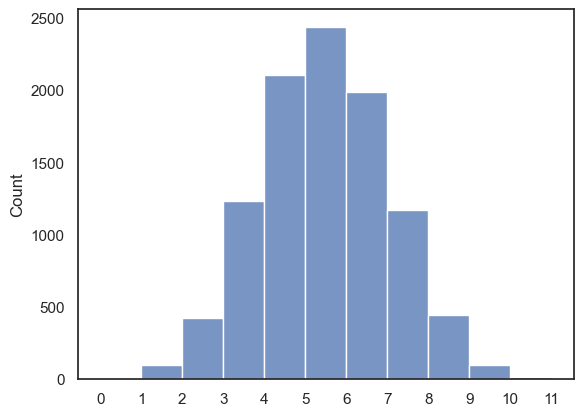

In [2]:
nReps = 10000
# make an empty np array to store the outcomes
k = np.empty(nReps)

for i in np.arange(len(k)): # we are going to simlulte 10,000 repeats of 10 coin tosses
    k[i] = np.random.binomial(10,0.5)

sns.histplot(x=k, bins=np.arange(0,12,1))
plt.xticks(np.arange(0, 12, 1))
plt.show()

In fact, we can even further simplify this process by again using the `size` argument to generate 10,000 values of $k$ for $n=10$ and $p=0.5$, in a single step:

In [3]:
k = np.random.binomial(10, 0.5, size=10000)

We demonstrate how this can be achieved using a loop because it is not always the case that you have a handy built-in function for generating the data from the distribution you want. In these cases you will need to rely on a loop.

### Frequency of each value of $k$

OK, now we have an array with 10,000 entries showing how many heads we got out of 10 coin tosses, in each of 10,000 repeats.

* **Remember:** one repeat or *rep* is one round of 10 coin tosses; the outcome for each *rep* is a value *k* (between 0 and 10), which is the number of 'heads'.

To summarize the outcomes of these 10,000 reps, we can use `sns.histplot()` like above or `sns.countplot()` like below to plot the frequencies of each value of $k$

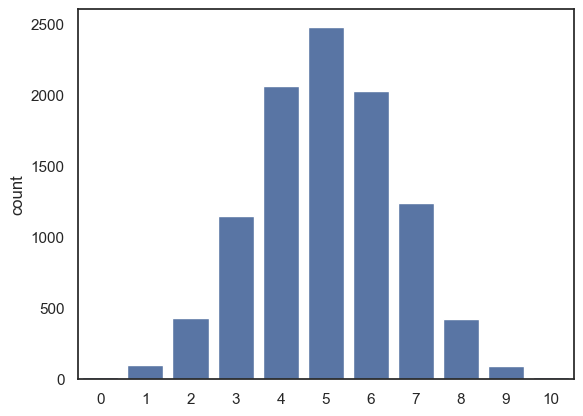

In [4]:
sns.countplot(x=k) 
plt.show()

We can see that 
* unsurprisingly, 5 is the most likely number of heads given $n=10$ and $p=0.5$
* values of $k$ close to 5 are also quite likely
* It is unlikely that we get 0 or 10 heads

### Probability of exactly 8 heads

All the values of $k$ for the 10000 repeats of the experiemnt are stored in the `numpy` array `k`. So that means any given index of k is a value between 0 and 10. you could print out the first five values using `print(k[:5])`

For every value in k we can check whether it is equal to 8 using the statement `k==8`. Remember this will return a list of Boolean values for every value in k. Specifically we will get `True` when that value equals 8 and `False` when it does not. If we take the mean of this Boolean array Python will treat `True` as 1 and `False` as 0 so the result is the proportion of all 10000 trials in which we obtained exactly 8 heads from the 10 tosses.

*Note: `np.mean(k==8)` would be equivalent to `sum(k==8) / len(k)`*

In [5]:
print(np.mean(k==8))

0.0418


... about 4%.

### Probability of at least 8 heads

You might not just be interested in one specific outcome, but instead in the probability of obtaining a value of k that is equal or greater tahn a certain threshold. For example, what is the cahnge of getting 8 *or more* heads out of the 10 tosses of a fair coin. 

For this we can use the same trick as above - transform our $k$ array into a Boolean array, and calculate the mean. 

In [6]:
print(np.mean(k>=8))
#sum(k>=8)/len(k)

0.0519


... ~ 5.5%